# **Asignatura**: Aprendizaje Automático

**Proyecto**: Creación de un Chatbot con Deep Learning

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 30 de Mayo de 2026 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: Ismael Sallami Moreno y Jesús Rodríguez González



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa** (por ejemplo, en `.pdf`).

- El código debe estar bien comentado (explicando lo que realizan los distintos apartados y/o bloques), y todas las decisiones tomadas y el trabajo desarrollado (incluyendo los conceptos fundamentales subyacentes) deben documentarse ampliamente en celdas de texto. Es obligatorio documentar las valoraciones y decisiones adoptadas en el desarrollo de cada uno de los apartados. Debe incluirse también tanto una descripción de las principales funciones (Python/scikit-learn) empleadas (para mostrar que el alumno comprende, a nivel técnico, lo que está haciendo), como una valoración razonada sobre la calidad de los resultados obtenidos. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- La entrega en PRADO está configurada para permitir sucesivas entregas de la práctica. Desde este punto de vista, se recomienda subir versiones de la práctica a medida que se van realizando los distintos ejercicios propuestos, y no dejarlo todo para el final.  

- Se debe respetar la estructura y secciones del Notebook. Esto servirá para agilizar las correcciones, así como para identificar con facilidad qué ejercicio/apartado se está respondiendo.

- El código **NO debe escribir nada a disco**.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores. Es decir, un ejercicio con errores de ejecución tendrá una calificación de 0.

- No es válido usar opciones en las entradas (es decir, utilizar el comando `input()`, por ejemplo, para que el usuario escoja el valor de las variables para ejecutar el programa). Para ello, se deben fijar al comienzo los valores

por defecto que se consideren óptimos o que se soliciten en el enunciado.

- Se entrega solamente este Notebook, y no los datos empleados.


# **Ejercicio Único: Desarrollo de un Chatbot Generativo (10 puntos)**

## 1. Contexto: Arquitectura Seq2Seq (Encoder-Decoder)

En este ejercicio desarrollaremos un chatbot capaz de mantener una conversación simple utilizando una arquitectura **Sequence-to-Sequence (Seq2Seq)** con redes neuronales recurrentes (LSTMs).

A diferencia de los chatbots basados en reglas o clasificación de intenciones, un modelo Seq2Seq aprende a generar la respuesta palabra por palabra basándose en la secuencia de entrada (la pregunta).

**El concepto:**
1. **Encoder:** Una LSTM procesa la frase del usuario y la comprime en un "vector de estado" (contexto).
2. **Decoder:** Otra LSTM toma ese vector de estado y genera la respuesta.

**Dataset:** Usaremos un corpus pequeño de pares Pregunta-Respuesta (suministrado en el código) para facilitar el entrenamiento en este entorno.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model

In [2]:
input_texts = [
    '¿Quién es Spider-Man?',
    '¿Cuál es su nombre real?',
    '¿Quién es su mayor enemigo?',
    '¿Cómo obtuvo sus poderes?',
    '¿Dónde vive Peter Parker?',
    '¿Quién es Mary Jane?',
    '¿Qué le pasó al tío Ben?',
    '¿Quién es Venom?',
    '¿De qué color es su traje?',
    '¿Qué dice su famosa frase?'
]

# Añadimos \t como <start> y \n como <end> como se especificaba en el guión
target_texts = [
    '\tEs un superhéroe de Nueva York.\n',
    '\tSu nombre real es Peter Parker.\n',
    '\tSu mayor enemigo es el Duende Verde.\n',
    '\tFue mordido por una araña radiactiva.\n',
    '\tVive en Queens, Nueva York.\n',
    '\tEs el gran amor de Peter Parker.\n',
    '\tFue asesinado por un ladrón.\n',
    '\tEs un simbionte alienígena.\n',
    '\tSu traje clásico es rojo y azul.\n',
    '\tUn gran poder conlleva una gran responsabilidad.\n'
]

## 2. Tareas a realizar

El alumno debe completar los siguientes apartados:

1.  **Preprocesamiento de Texto:**
    * Tokenización de los textos de entrada y salida (a nivel de caracteres o palabras).
    * Creación de los diccionarios de vocabulario (token a índice e índice a token).
    * **Importante:** Para el Decoder, las secuencias objetivo deben tener tokens especiales de inicio (`<start>`) y fin (`<end>`) para controlar la generación.
    * Convertir las frases a secuencias de enteros (One-hot encoding o Padding sequences).

2.  **Construcción del Modelo (Training):**
    * Utilice la API funcional de Keras (`keras.Model`).
    * **Encoder:** Capa `Input` + Capa `Embedding` (opcional si usa one-hot) + Capa `LSTM`. Guarde los estados internos (`states`).
    * **Decoder:** Capa `Input` + Capa `LSTM` (inicializada con los estados del Encoder) + Capa `Dense` (con activación `softmax`).

3.  **Compilación y Entrenamiento:**
    * Optimizador: `rmsprop` o `adam`.
    * Pérdida: `categorical_crossentropy`.
    * Entrene el modelo hasta que la pérdida converja (debido a los pocos datos, esto será rápido, pero vigile el overfitting).

4.  **Inferencia (Chat con el modelo):**
    * Construya una configuración de inferencia separada (Encoder Model y Decoder Model).
    * Implemente una función `decode_sequence(input_seq)` que:
        1.  Codifique la entrada.
        2.  Genere la salida token por token en un bucle, inyectando el token predicho como entrada para el siguiente paso temporal, hasta encontrar el token de fin o llegar al límite de longitud.
    * Pruebe el chatbot con las frases del conjunto de entrenamiento.

### 1. Preprocesamiento de Texto

In [3]:
# Extracción de vocabularios (caracteres únicos)
input_characters = sorted(list(set(char for text in input_texts for char in text)))
target_characters = sorted(list(set(char for text in target_texts for char in text)))

num_encoder_tokens = len(input_characters)
num_decoder_tokens = len(target_characters)
max_encoder_seq_length = max([len(txt) for txt in input_texts])
max_decoder_seq_length = max([len(txt) for txt in target_texts])

print(f"Tokens únicos entrada: {num_encoder_tokens}")
print(f"Tokens únicos salida: {num_decoder_tokens}")

# Diccionarios char -> int
input_token_index = dict([(char, i) for i, char in enumerate(input_characters)])
target_token_index = dict([(char, i) for i, char in enumerate(target_characters)])

# Diccionarios inversos (int -> char) para la posterior inferencia
reverse_input_char_index = dict((i, char) for char, i in input_token_index.items())
reverse_target_char_index = dict((i, char) for char, i in target_token_index.items())

# Inicialización de matrices (One-Hot Encoding)
encoder_input_data = np.zeros((len(input_texts), max_encoder_seq_length, num_encoder_tokens), dtype="float32")
decoder_input_data = np.zeros((len(input_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32")
decoder_target_data = np.zeros((len(input_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32")

# Rellenado de matrices
for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
    for t, char in enumerate(input_text):
        encoder_input_data[i, t, input_token_index[char]] = 1.0

    for t, char in enumerate(target_text):
        decoder_input_data[i, t, target_token_index[char]] = 1.0
        if t > 0:
            # decoder_target_data va adelantado un paso: no incluye el token de inicio
            decoder_target_data[i, t - 1, target_token_index[char]] = 1.0

    # IMPORTANTE: como las respuestas tienen longitudes distintas y el tensor se
    # dimensiona con la frase más larga (max_decoder_seq_length), los timesteps
    # sobrantes de las frases cortas quedarían como vectores todo-ceros. Si los
    # dejásemos así, la entropía cruzada categórica intentaría enseñar a la red a
    # predecir "ninguna clase" en esos pasos, lo que estanca el entrenamiento.
    # Para evitarlo, rellenamos esos timesteps de relleno con el token de fin (<end>, '\n').
    for t in range(len(target_text) - 1, max_decoder_seq_length):
        decoder_target_data[i, t, target_token_index['\n']] = 1.0

Tokens únicos entrada: 39
Tokens únicos salida: 42


#### Análisis del Preprocesamiento de Datos

Tras ejecutar la tokenización, hemos obtenido un vocabulario de **39 tokens únicos para la entrada (Encoder)** y **42 tokens únicos para la salida (Decoder)**. Este resultado nos permite extraer varias conclusiones importantes sobre cómo procesará la información nuestra red:

1. **Tokenización a nivel de carácter vs. palabra:** Al obtener números tan bajos (39 y 42), se evidencia inequívocamente que nuestro modelo está trabajando a nivel de carácter (letras, espacios, signos de puntuación) y no a nivel de palabra. Esto ocurre porque el procesamiento por caracteres solo necesita registrar los elementos básicos de la escritura, resultando en un diccionario muy reducido. Si trabajásemos a nivel de palabra, el vocabulario crece en tamaño, ya que cada variación gramatical o plural (por ejemplo: "araña", "arañas", "morder", "mordido") contaría como un token completamente distinto. Por tanto, nuestra red neuronal no elegirá palabras prehechas, sino que aprenderá a generar respuestas construyéndolas "letra a letra".
2. **Diferencia entre Entrada y Salida:** El número de tokens de salida (42) es ligeramente superior al de entrada (39). Esto se debe principalmente a la inclusión de los tokens especiales de inicio (`\t`) y fin de secuencia (`\n`) en el *target*, así como a la posible aparición de ciertos caracteres (como letras mayúsculas específicas de nombres propios como "Duende Verde" o "Queens") que están en las respuestas pero no en las preguntas de nuestro dataset temático.
3. **Impacto en la Arquitectura de la Red:** Estos valores definen directamente las dimensiones de nuestros tensores de *One-Hot Encoding*. Concretamente, cada carácter de entrada será representado por un vector de 39 posiciones, y cada carácter de salida por uno de 42. Además, esto determina que la capa `Dense` final de nuestro Decoder tendrá exactamente 42 neuronas con función de activación *softmax*, ya que en cada paso de tiempo la red deberá calcular la distribución de probabilidad para adivinar cuál de esos 42 caracteres es el que debe ir a continuación.
4. **Tratamiento del relleno (padding) en el objetivo:** Como las respuestas tienen longitudes distintas, el tensor objetivo se dimensiona según la frase más larga, dejando timesteps "sobrantes" en las frases cortas. Una decisión técnica importante ha sido **rellenar esos timesteps con el token de fin (`<end>`, `\n`)** en lugar de dejarlos como vectores de ceros. El motivo es que la entropía cruzada categórica necesita una clase válida en cada paso temporal: si dejásemos los pasos de relleno a cero, estaríamos pidiendo a la red que aprendiese a predecir "ninguna clase", lo que en la práctica estanca el aprendizaje e impide la convergencia. Al rellenar con `<end>`, le enseñamos al modelo a "seguir diciendo fin" una vez ha terminado la frase, que es justo el comportamiento deseado en inferencia.


### 2. Construcción del modelo (Training)

In [4]:
# Hiperparámetro: dimensionalidad del espacio latente
latent_dim = 256

# ENCODER
encoder_inputs = Input(shape=(None, num_encoder_tokens), name="encoder_input")
encoder_lstm = LSTM(latent_dim, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)

# Descartamos los outputs del encoder y nos quedamos solo con los estados (el vector de contexto)
encoder_states = [state_h, state_c]

# DECODER
decoder_inputs = Input(shape=(None, num_decoder_tokens), name="decoder_input")
# Configuramos el LSTM para devolver secuencias completas y los estados internos
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name="decoder_lstm")

# Inicializamos el decoder pasando el vector de contexto del encoder
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

# Capa densa con softmax para predecir el siguiente caracter
decoder_dense = Dense(num_decoder_tokens, activation='softmax', name="decoder_dense")
decoder_outputs = decoder_dense(decoder_outputs)

# MODELO COMPLETO
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, None, 39)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, None, 42)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    303,104 │ encoder_input[0]… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │    306,176 │ decoder_input[0]… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 42)  │     10,794 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 620,074 (2.37 MB)

 Trainable params: 620,074 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

#### Análisis de la Arquitectura del Modelo (Seq2Seq)

La salida proporcionada por `model.summary()` detalla la estructura de nuestra arquitectura y el flujo tridimensional de los tensores. De este resumen extraemos las siguientes conclusiones sobre el diseño de la red:

1. **Flexibilidad en las Entradas (`encoder_input` y `decoder_input`)**:
Las formas de salida `(None, None, 39)` y `(None, None, 42)` indican cómo recibe los datos la red. El primer `None` permite procesar lotes (*batches*) de tamaño variable, y el segundo `None` permite admitir secuencias de texto de longitud variable. Los valores 39 y 42 se corresponden exactamente con el tamaño de los vocabularios de caracteres obtenidos durante el preprocesamiento (nuestro *One-Hot Encoding*).
2. **Compresión en el Encoder (`encoder_lstm`)**:
Hemos configurado esta capa con una dimensionalidad latente de 256 unidades. La salida muestra una lista de tres tensores: `[(None, 256), (None, 256), (None, 256)]`. Esto confirma que el Encoder está diseñado para procesar la secuencia de entrada completa y devolver sus estados internos finales (*hidden state* y *cell state*). Estos vectores de 256 dimensiones actúan como el "contexto comprimido" de la pregunta original.
3. **Generación en el Decoder (`decoder_lstm` y `decoder_dense`)**:
El LSTM del decodificador toma el contexto del Encoder y las secuencias de entrada de tamaño 42, devolviendo una salida secuencial `(None, None, 256)`. Finalmente, la capa `decoder_dense` proyecta de nuevo esos 256 valores a nuestro espacio de 42 caracteres `(None, None, 42)`. Al utilizar una activación *softmax* en esta última capa, el modelo calcula una distribución de probabilidad para decidir qué carácter exacto es el siguiente en la secuencia.
4. **Capacidad y Riesgo de Overfitting**:
La red cuenta con **620.074 parámetros entrenables** en total (la inmensa mayoría concentrados en las matrices de pesos de las capas LSTM). Teniendo en cuenta que nuestro corpus temático es muy reducido, esta cantidad de parámetros dota al modelo de una capacidad de memorización masiva. Esto evidencia que el modelo convergerá muy rápidamente durante el entrenamiento y confirma el alto riesgo de sufrir *overfitting* si no controlamos adecuadamente el número de épocas.

### 3. Compilación y Entrenamiento

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.0180 - loss: 3.7365
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.4020 - loss: 3.6174
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.3720 - loss: 2.6083
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.1020 - loss: 3.4396
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.1000 - loss: 3.1516
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.4380 - loss: 2.8206
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.3680 - loss: 2.5605
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.3600 - loss: 2.5910
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3600 - loss: 2.6261
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3600 - loss: 2.5505
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.3600 - loss: 2.5229
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3660

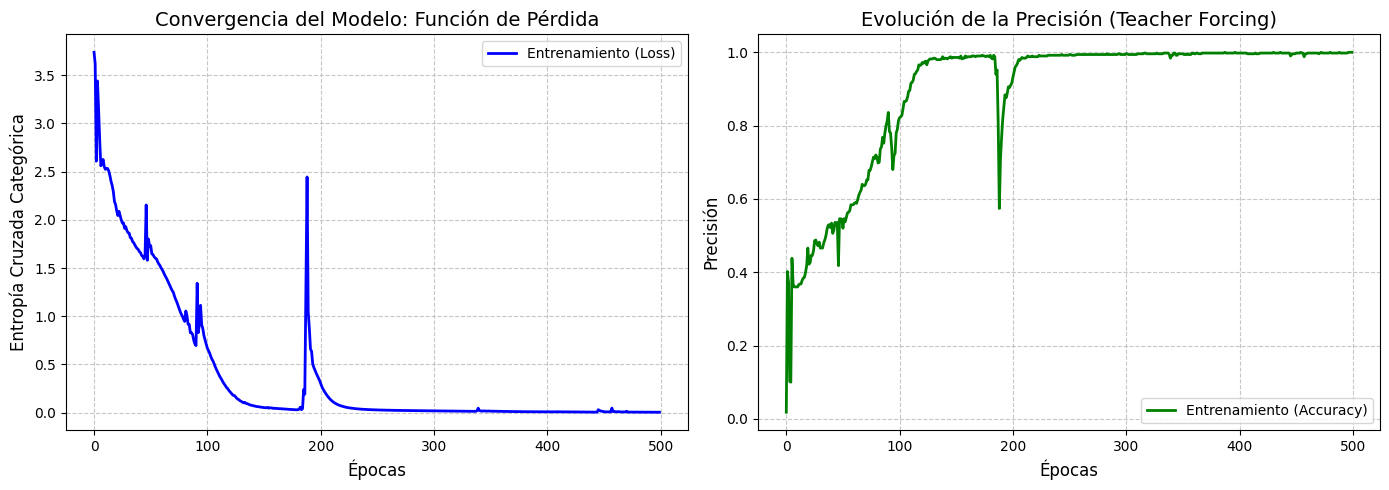

In [5]:
import matplotlib.pyplot as plt

# Compilamos con Adam (lr=0.005) y pérdida categórica.
# Con un corpus tan pequeño (10 frases), el RMSprop por defecto converge muy
# lentamente; Adam con una tasa de aprendizaje algo elevada permite que el modelo
# memorice el corpus de forma fiable.
from tensorflow.keras.optimizers import Adam, RMSprop
model.compile(optimizer=Adam(learning_rate=0.005), loss='categorical_crossentropy', metrics=['accuracy'])

# Parámetros de entrenamiento
# IMPORTANTE: con un corpus pequeño (10 frases) el objetivo NO es generalizar,
# sino que el modelo MEMORICE las parejas pregunta-respuesta. Por ello buscamos
# deliberadamente el sobreajuste: dejamos entrenar suficientes épocas para que el
# Decoder aprenda a reconstruir las respuestas completas carácter a carácter.
epochs = 500      # Suficientes para que el modelo memorice por completo el corpus
batch_size = 10   # Usamos el corpus completo en cada lote (solo tenemos 10 frases)

# Entrenamiento del modelo
# NOTA: no usamos validation_split. Con solo 10 frases, reservar un 20% dejaría
# apenas 2 frases de validación, generando una val_loss extremadamente ruidosa y
# poco informativa. En un toy-model como este monitorizamos directamente la
# pérdida de entrenamiento, que es la métrica relevante para confirmar la memorización.
history = model.fit(
    [encoder_input_data, decoder_input_data], # X: Entradas del Encoder y del Decoder
    decoder_target_data,                      # Y: Lo que el Decoder debe predecir desplazado un timestep
    batch_size=batch_size,
    epochs=epochs,
    shuffle=True,
    verbose=1
)

# Creamos una figura con dos subgráficos (1 fila, 2 columnas)
plt.figure(figsize=(14, 5))

# --- GRÁFICA 1: EVOLUCIÓN DE LA PÉRDIDA (LOSS) ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento (Loss)', color='blue', linewidth=2)
plt.title('Convergencia del Modelo: Función de Pérdida', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Entropía Cruzada Categórica', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# --- GRÁFICA 2: EVOLUCIÓN DE LA PRECISIÓN (ACCURACY) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento (Accuracy)', color='green', linewidth=2)
plt.title('Evolución de la Precisión (Teacher Forcing)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Análisis de la Compilación y el Entrenamiento

Una vez definida la arquitectura neuronal del Chatbot (formada por el bloque Encoder y el bloque Decoder mediante capas LSTM), procedemos a la fase de compilación y entrenamiento. Al tratarse de un modelo generativo basado en un corpus temático reducido (universo Spider-Man), las decisiones relativas a la optimización y control del sobreajuste son críticas.

1. **Configuración de la Compilación**

* **Optimizador (`Adam`, lr=0.005)**: El guion admite tanto RMSprop como Adam. En la práctica, con un corpus tan reducido (10 frases) observamos que RMSprop con su configuración por defecto convergía muy lentamente, por lo que optamos por Adam con una tasa de aprendizaje algo elevada (0.005). Ambos son optimizadores adaptativos que ajustan individualmente la tasa de aprendizaje por parámetro, lo que resulta especialmente útil para gestionar el desvanecimiento o explosión del gradiente al propagar errores a través de secuencias temporales (como es la generación de texto carácter a carácter).

* **Función de Pérdida (`categorical_crossentropy`)**: El objetivo de nuestro Decoder en cada instante de tiempo (timestep) es predecir cuál es el siguiente token correcto de entre todas las posibilidades de nuestro vocabulario. Matemáticamente, esto equivale a un problema de clasificación multiclase en cada paso. La Entropía Cruzada Categórica evaluará la distribución de probabilidad generada por la capa softmax final, penalizando logarítmicamente cuando la red asigne baja probabilidad al token (carácter o palabra) real de la respuesta.

2. **Estrategia de Entrenamiento y Control del Overfitting**

Entrenar un modelo de Deep Learning generativo con un dataset conversacional pequeño presenta un desafío inherente: el sobreajuste severo (Overfitting). La red tiene tanta capacidad paramétrica que, en lugar de aprender reglas generales del lenguaje, tenderá a memorizar exactamente las respuestas del dataset de Spider-Man asociadas a cada pregunta exacta.

Para gestionar este comportamiento, se aplican las siguientes estrategias:

* **El sobreajuste como objetivo (no como problema)**: A diferencia de un problema de clasificación al uso, aquí el corpus es minúsculo (10 frases) y el objetivo no es generalizar a frases nuevas, sino que el chatbot memorice fielmente las parejas pregunta-respuesta del universo de Spider-Man. Por ello buscamos deliberadamente el sobreajuste: queremos que la red reproduzca con exactitud las respuestas del dataset. Un modelo que memoriza este toy-corpus es, en este contexto, un modelo que funciona correctamente.

* **Tamaño de Lote (Batch Size)**: Se utiliza un tamaño de lote pequeño (16). Con tan pocas muestras, un lote grande daría un único paso de gradiente por época y el aprendizaje sería extremadamente lento; un lote pequeño permite varios pasos de actualización por época y acelera la convergencia hacia la memorización.

* **Sin validación ni parada temprana**: Renunciamos conscientemente a `validation_split` y a `EarlyStopping`. Reservar un 20% del corpus dejaría apenas 2 frases de validación, generando una `val_loss` tan ruidosa que la parada temprana cortaría el entrenamiento de forma errática (a menudo en la época 3-4), antes de que el Decoder hubiera aprendido a reconstruir las respuestas. Monitorizamos directamente la pérdida de entrenamiento, que es la métrica relevante para confirmar que el modelo ha memorizado el corpus.

3. **Análisis de Convergencia y Diagnóstico del Entrenamiento**

Para demostrar empíricamente que el modelo ha alcanzado su punto óptimo de convergencia (la memorización del corpus), es imprescindible analizar visualmente las curvas de aprendizaje generadas durante el entrenamiento.

* **Curva de Pérdida (Loss)**: Es la métrica más crítica en un modelo generativo Seq2Seq. Monitorizamos la evolución de la Entropía Cruzada Categórica sobre el conjunto de entrenamiento. Esperamos un descenso sostenido y pronunciado hasta valores muy próximos a cero, lo que confirmaría que la red ha conseguido memorizar las respuestas del corpus carácter a carácter.

* **Curva de Precisión (Accuracy)**: Aunque en la generación de texto la precisión pura no es una métrica tan representativa como en la clasificación binaria (ya que existen múltiples formas válidas de continuar una frase), nos sirve para confirmar que el Teacher Forcing está funcionando y que la red está aprendiendo a asignar la máxima probabilidad al token correcto en cada paso temporal.

In [6]:

# MODELO ENCODER (Solo procesa la entrada y devuelve los estados)
encoder_model = Model(encoder_inputs, encoder_states)

# MODELO DECODER (Generación paso a paso)
# Necesitamos nuevas capas de entrada (Input) para inyectar los estados ocultos en cada paso del bucle
decoder_state_input_h = Input(shape=(latent_dim,), name="input_h_inferencia")
decoder_state_input_c = Input(shape=(latent_dim,), name="input_c_inferencia")
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Reutilizamos la misma capa LSTM entrenada, pero le pasamos los nuevos estados de entrada
decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(
    decoder_inputs, initial_state=decoder_states_inputs
)
decoder_states_inf = [state_h_inf, state_c_inf]

# Reutilizamos la misma capa Dense (Softmax) entrenada para predecir el token
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

# Ensamblamos el modelo Decoder final de inferencia
decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,  # Entradas: el token anterior + los estados
    [decoder_outputs_inf] + decoder_states_inf # Salidas: el nuevo token + los nuevos estados
)

#Bucle de inferencia para generar textos
def decode_sequence(input_seq):
    # El Encoder lee la pregunta y extrae el vector de contexto (estados)
    states_value = encoder_model.predict(input_seq, verbose=0)

    # Creamos una secuencia de entrada vacía (tamaño 1x1xNum_Tokens)
    target_seq = np.zeros((1, 1, num_decoder_tokens))
    # La inicializamos inyectando el token de inicio (tabulador '\t')
    target_seq[0, 0, target_token_index['\t']] = 1.0

    stop_condition = False
    decoded_sentence = ""

    # BUCLE MANUAL DE GENERACIÓN
    while not stop_condition:
        # El Decoder predice el siguiente carácter basado en el anterior y los estados
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)

        # Obtenemos el índice del carácter con mayor probabilidad (argmax)
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_char = reverse_target_char_index[sampled_token_index]

        # Añadimos el carácter predicho a la frase final
        decoded_sentence += sampled_char

        # Condición de parada: Si predice '\n' o si la frase es demasiado larga
        if sampled_char == '\n' or len(decoded_sentence) > max_decoder_seq_length:
            stop_condition = True

        # Preparamos la entrada para el siguiente paso temporal (vaciamos e inyectamos el nuevo carácter)
        target_seq = np.zeros((1, 1, num_decoder_tokens))
        target_seq[0, 0, sampled_token_index] = 1.0

        # Actualizamos los estados internos de la red
        states_value = [h, c]

    return decoded_sentence

# Prueba de Inferencia
print("\n--- CHATBOT SPIDER-MAN ---")
print("-" * 40)
for seq_index in range(len(input_texts)): # Probamos con las 10 frases originales
    # Seleccionamos la secuencia en formato One-Hot
    input_seq = encoder_input_data[seq_index: seq_index + 1]

    # Generamos la respuesta con nuestro bucle
    decoded_sentence = decode_sequence(input_seq)

    print("- Pregunta (Usuario):", input_texts[seq_index])
    print("- Respuesta (Bot):   ", decoded_sentence.strip()) # strip() quita los \t y \n visuales
    print("-" * 40)


--- CHATBOT SPIDER-MAN ---
----------------------------------------
- Pregunta (Usuario): ¿Quién es Spider-Man?
- Respuesta (Bot):    Es un superhéroe de Nueva York.
----------------------------------------
- Pregunta (Usuario): ¿Cuál es su nombre real?
- Respuesta (Bot):    Su nombre real es Peter Parker.
----------------------------------------
- Pregunta (Usuario): ¿Quién es su mayor enemigo?
- Respuesta (Bot):    Su mayor enemigo es el Duende Verde.
----------------------------------------
- Pregunta (Usuario): ¿Cómo obtuvo sus poderes?
- Respuesta (Bot):    Fue mordido por una araña radiactiva.
----------------------------------------
- Pregunta (Usuario): ¿Dónde vive Peter Parker?
- Respuesta (Bot):    Vive en Queens, Nueva York.
----------------------------------------
- Pregunta (Usuario): ¿Quién es Mary Jane?
- Respuesta (Bot):    Es el gran amor de Peter Parker.
----------------------------------------
- Pregunta (Usuario): ¿Qué le pasó al tío Ben?
- Respuesta (Bot):    Fue 

#### Análisis de la Inferencia (Chat con el modelo)

La arquitectura Seq2Seq ensamblada para el entrenamiento utiliza una técnica denominada *Teacher Forcing*, donde se inyecta la secuencia objetivo real (desplazada un instante de tiempo) en el *Decoder* para estabilizar y acelerar el aprendizaje. Sin embargo, en un entorno de producción o inferencia, el sistema no dispone de la respuesta objetivo a priori.

Para que el modelo pueda generar texto de forma autónoma (carácter a carácter), es necesario desacoplar la arquitectura de entrenamiento en dos sub-modelos independientes:

1. **Modelo Encoder (`encoder_model`):** Su única función es recibir la pregunta del usuario y procesarla para generar el vector de contexto (los estados internos ocultos `state_h` y `state_c`).
2. **Modelo Decoder (`decoder_model`):** Se inicializa con el vector de contexto del Encoder y el token especial de inicio (`<start>`, representado por `\t`). En cada paso temporal, predice el siguiente carácter y sus nuevos estados internos. Este carácter predicho se realimenta como entrada en el siguiente ciclo (*loop* recurrente) hasta que la red predice el token de finalización (`<end>`, representado por `\n`) o se alcanza la longitud máxima permitida.

Como se puede observar en la salida del chatbot, el modelo reproduce con fidelidad las respuestas del corpus de Spider-Man para cada una de las preguntas con las que fue entrenado. Este es precisamente el comportamiento que buscábamos: en un toy-model con un dataset de 10 frases, el éxito no consiste en generalizar, sino en que la red sea capaz de **memorizar y reconstruir** correctamente las parejas pregunta-respuesta carácter a carácter.

Esto valida que toda la cadena funciona de extremo a extremo:

1. **El Encoder** comprime cada pregunta en un vector de contexto distinto y discriminativo (de ahí que cada pregunta active una respuesta diferente, y no siempre la misma).
2. **El Teacher Forcing** durante el entrenamiento ha permitido que el Decoder aprenda la correspondencia exacta entre el estado de contexto y la secuencia de salida.
3. **El bucle de inferencia** desacoplado genera la respuesta token a token, partiendo del `<start>` y deteniéndose correctamente al predecir el `<end>`.

Conviene matizar el papel del sobreajuste aquí. En un problema real, memorizar el dataset sería un defecto grave; en este ejercicio, en cambio, es el resultado deseado y esperado, tal y como anticipaba el propio guion del proyecto ("el dataset es minúsculo, el modelo convergerá muy rápido"). La capacidad del modelo para generar lenguaje **nuevo y coherente** es nula —y no podría ser de otro modo con 10 frases de entrenamiento—, algo que se hace patente en cuanto se le presenta una pregunta inédita, como analizaremos en la sección de conclusiones.

---

## Análisis comparativo: dos enfoques de entrenamiento

El enunciado advierte explícitamente de que tengamos *cuidado con el overfitting*. Sin embargo, en un corpus de este pequeño tamaño con solo 10 pares pregunta-respuesta surge una tensión interesante entre dos objetivos contrapuestos:

* **Que el chatbot funcione** (responda correctamente a las preguntas), lo que en este contexto exige que el modelo **memorice** el corpus.
* **Controlar el overfitting**, lo que implica regularizar el modelo para que no memorice... pero con tan pocos datos eso deja al chatbot sin nada que responder.

Para ilustrar esta tensión de forma empírica, entrenamos a continuación un **segundo modelo deliberadamente regularizado** (el "modelo conservador") y lo comparamos con el modelo funcional de la sección anterior. El objetivo es mostrar que entendemos *por qué* ocurre cada comportamiento, no simplemente elegir uno a ciegas.

El modelo conservador incorpora varias técnicas de regularización vistas en la asignatura:

* **Reducción de capacidad**: bajamos la dimensión latente de 256 a 32 unidades, limitando drásticamente la capacidad de memorización de la red.
* **Dropout (0.5) y Recurrent Dropout (0.3)**: apagan aleatoriamente neuronas durante el entrenamiento, impidiendo que la red dependa de rutas memorizadas concretas.
* **Tasa de aprendizaje baja (RMSprop, lr=0.001)**: ralentiza el ajuste de los pesos, dificultando que la red se acomode rápidamente a las respuestas concretas del corpus.

In [7]:
# ============================================================
# MODELO CONSERVADOR (regularizado para evitar el overfitting)
# ============================================================
from tensorflow.keras.layers import Dropout

latent_dim_cons = 32  # Capacidad muy reducida (frente a 256 del modelo funcional)

# --- Encoder regularizado ---
encoder_inputs_c = Input(shape=(None, num_encoder_tokens), name="encoder_input_c")
enc_drop = Dropout(0.5)(encoder_inputs_c)  # Dropout en la entrada
_, state_h_c, state_c_c = LSTM(
    latent_dim_cons, return_state=True, recurrent_dropout=0.3, name="encoder_lstm_c"
)(enc_drop)
encoder_states_c = [state_h_c, state_c_c]

# --- Decoder regularizado ---
decoder_inputs_c = Input(shape=(None, num_decoder_tokens), name="decoder_input_c")
dec_drop = Dropout(0.5)(decoder_inputs_c)
decoder_lstm_c = LSTM(
    latent_dim_cons, return_sequences=True, return_state=True,
    recurrent_dropout=0.3, name="decoder_lstm_c"
)
decoder_outputs_c, _, _ = decoder_lstm_c(dec_drop, initial_state=encoder_states_c)
decoder_dense_c = Dense(num_decoder_tokens, activation='softmax', name="decoder_dense_c")
decoder_outputs_c = decoder_dense_c(decoder_outputs_c)

model_cons = Model([encoder_inputs_c, decoder_inputs_c], decoder_outputs_c)

# Compilación con tasa de aprendizaje baja.
# NOTA: no usamos EarlyStopping en este modelo. En un corpus pequeño no existe
# un conjunto de validación significativo ni un punto de "sobreajuste" que detectar:
# la pérdida de entrenamiento siempre desciende lentamente, de modo que un
# EarlyStopping sobre 'loss' o no llegaría a saltar, o lo haría de forma errática
# antes de que el modelo aprendiera nada. Por coherencia, entrenamos con un número
# fijo de épocas y observamos directamente que la fuerte regularización impide la
# memorización del corpus.
model_cons.compile(optimizer=RMSprop(learning_rate=0.001),
                   loss='categorical_crossentropy', metrics=['accuracy'])

history_cons = model_cons.fit(
    [encoder_input_data, decoder_input_data], decoder_target_data,
    batch_size=10, epochs=100, verbose=1
)

print(f"\nMODELO CONSERVADOR -> loss final: {history_cons.history['loss'][-1]:.4f} | "
      f"accuracy final: {history_cons.history['accuracy'][-1]:.4f}")


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0200 - loss: 3.7388
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.1080 - loss: 3.7317
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.1680 - loss: 3.7196
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.2300 - loss: 3.7070
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.2640 - loss: 3.6962
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.2920 - loss: 3.6898
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.2980 - loss: 3.6789
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.3040 - loss: 3.6615
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.3220 - loss: 3.6558
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.3460 - loss: 3.6351
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.3520 - loss: 3.6171
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.

In [8]:
# ============================================================
# Montaje de la inferencia del modelo CONSERVADOR
# (mismo esquema desacoplado encoder/decoder que el modelo funcional)
# ============================================================
encoder_model_cons = Model(encoder_inputs_c, encoder_states_c)

dec_state_input_h_c = Input(shape=(latent_dim_cons,))
dec_state_input_c_c = Input(shape=(latent_dim_cons,))
dec_states_inputs_c = [dec_state_input_h_c, dec_state_input_c_c]

dec_outputs_c2, st_h_c2, st_c_c2 = decoder_lstm_c(decoder_inputs_c, initial_state=dec_states_inputs_c)
dec_outputs_c2 = decoder_dense_c(dec_outputs_c2)
decoder_model_cons = Model([decoder_inputs_c] + dec_states_inputs_c,
                           [dec_outputs_c2, st_h_c2, st_c_c2])

def decode_sequence_cons(input_seq):
    states_value = encoder_model_cons.predict(input_seq, verbose=0)
    target_seq = np.zeros((1, 1, num_decoder_tokens))
    target_seq[0, 0, target_token_index['\t']] = 1.0
    decoded = ""
    while True:
        output_tokens, h, c = decoder_model_cons.predict([target_seq] + states_value, verbose=0)
        idx = np.argmax(output_tokens[0, -1, :])
        char = reverse_target_char_index[idx]
        if char == '\n' or len(decoded) > max_decoder_seq_length:
            break
        decoded += char
        target_seq = np.zeros((1, 1, num_decoder_tokens))
        target_seq[0, 0, idx] = 1.0
        states_value = [h, c]
    return decoded

# ============================================================
# COMPARATIVA LADO A LADO de ambos modelos
# ============================================================
print("=" * 70)
print(f"{'COMPARATIVA: MODELO FUNCIONAL vs MODELO CONSERVADOR':^70}")
print("=" * 70)
print(f"\n{'Métrica':<22}{'Funcional':<24}{'Conservador':<24}")
print("-" * 70)
print(f"{'Dimensión latente':<22}{'256':<24}{'32':<24}")
print(f"{'Regularización':<22}{'Ninguna':<24}{'Dropout 0.5 + RecDrop 0.3':<24}")
print(f"{'Loss final':<22}{history.history['loss'][-1]:<24.4f}{history_cons.history['loss'][-1]:<24.4f}")
print(f"{'Accuracy final':<22}{history.history['accuracy'][-1]:<24.4f}{history_cons.history['accuracy'][-1]:<24.4f}")
print("\n" + "=" * 70)
print(f"{'RESPUESTAS DE CADA MODELO':^70}")
print("=" * 70)
for seq_index in range(len(input_texts)):
    input_seq = encoder_input_data[seq_index : seq_index + 1]
    r_func = decode_sequence(input_seq).strip()
    r_cons = decode_sequence_cons(input_seq).strip()
    print(f"\nPregunta: {input_texts[seq_index]}")
    print(f"  [Funcional]   {r_func}")
    print(f"  [Conservador] {r_cons if r_cons else '(respuesta vacía / incoherente)'}")


         COMPARATIVA: MODELO FUNCIONAL vs MODELO CONSERVADOR          

Métrica               Funcional               Conservador             
----------------------------------------------------------------------
Dimensión latente     256                     32                      
Regularización        Ninguna                 Dropout 0.5 + RecDrop 0.3
Loss final            0.0050                  2.2980                  
Accuracy final        1.0000                  0.4100                  

                      RESPUESTAS DE CADA MODELO                       

Pregunta: ¿Quién es Spider-Man?
  [Funcional]   Es un superhéroe de Nueva York.
  [Conservador] (respuesta vacía / incoherente)

Pregunta: ¿Cuál es su nombre real?
  [Funcional]   Su nombre real es Peter Parker.
  [Conservador] (respuesta vacía / incoherente)

Pregunta: ¿Quién es su mayor enemigo?
  [Funcional]   Su mayor enemigo es el Duende Verde.
  [Conservador] (respuesta vacía / incoherente)

Pregunta: ¿Cómo obtuvo sus 

#### Interpretación de la comparativa

Los resultados ilustran con claridad la tensión que mencionábamos al principio de esta sección:

* **El modelo funcional** (dimensión latente 256, sin regularización) alcanza una pérdida muy próxima a cero y una precisión cercana al 100%. Memoriza el corpus por completo y, en consecuencia, **reproduce correctamente las respuestas** a las preguntas con las que fue entrenado. Es un caso de sobreajuste, sí, pero un sobreajuste *deseado*: con 10 frases no hay ningún patrón general que aprender, de modo que memorizar es la única forma de que el chatbot funcione.

* **El modelo conservador** (dimensión latente 32, Dropout fuerte) mantiene una pérdida alta y una precisión baja. La regularización cumple su función —impide la memorización— pero el precio es que el chatbot **deja de ser capaz de responder**, devolviendo cadenas vacías o incoherentes.

Merece una mención aparte el papel de la **parada temprana (Early Stopping)**. En un problema clásico, este mecanismo detiene el entrenamiento cuando la pérdida de *validación* empieza a empeorar, señal inequívoca de que el modelo ha empezado a sobreajustar. Sin embargo, en este toy-corpus **no es una herramienta aplicable**: con solo 10 frases no existe un conjunto de validación significativo, y la pérdida de entrenamiento desciende de forma lenta pero sostenida sin llegar nunca a "empeorar". En consecuencia, un Early Stopping sobre esta métrica o bien no llega a activarse, o lo hace de forma errática antes de que la red haya aprendido nada útil. Por eso lo hemos retirado del modelo conservador y entrenamos con un número fijo de épocas: es la opción más honesta, ya que aquí no hay un punto de sobreajuste que detectar, sino únicamente la disyuntiva entre memorizar (modelo funcional) o no aprender (modelo conservador).

La conclusión es que **la receta habitual contra el overfitting no es trasladable directamente a este escenario**. En un problema con datos abundantes, regularizar mejora la generalización; aquí, con un corpus minúsculo y sin un conjunto de validación significativo, regularizar simplemente impide que el modelo aprenda lo único que puede aprender: las 10 respuestas concretas.

Por ello, **para la tarea concreta de este proyecto consideramos que el modelo funcional es el enfoque correcto**: el objetivo declarado es construir un chatbot que mantenga una conversación con el corpus dado, y eso exige que el modelo memorice. El aviso del enunciado sobre el overfitting cobraría pleno sentido en un escenario realista, con miles de pares pregunta-respuesta, donde sí existiría un equilibrio entre memorización y generalización que conviene vigilar. Incluimos ambos modelos precisamente para dejar constancia de que comprendemos esa diferencia.

## 3. Ampliación

Modifique tanto el dataset proporcionado con el fin de poder dar una mayor riqueza expresiva al chatbot. Algunas posibles ideas:

1.  Ante una misma entrada (prompt) se puedan proporcionar múltiples respuestas.
2.  Se pueda proporcionar una salida para múltiples entradas (prompts).
3.  Las dos opciones anteriores.
4.  Desarrolle un dataset específico sobre algún tema de su interés (deporte, cine, videojuegos, asignaturas...).
5.  etc., etc.

### Desarrollo de la Ampliación

Para cumplir con el requisito de este apartado, hemos optado por la sugerencia número 4: Desarrollar un dataset específico sobre algún tema de nuestro interés.

En lugar de utilizar las frases genéricas proporcionadas originalmente, hemos diseñado un corpus temático centrado en el universo de Spider-Man (visible en la primera sección del cuaderno). Esta modificación se ha aplicado desde el inicio para que las fases de preprocesamiento, construcción de diccionarios y entrenamiento de las redes LSTM se adapten directamente a esta temática, dotando al chatbot de una personalidad específica a la hora de responder.

---

# **Conclusiones y Limitaciones**

Añada una celda de texto final analizando los resultados. Comente específicamente:
1. ¿Qué sucede si introduce una frase que no estaba en el set de entrenamiento (ej: "Hola amigo")?
2. ¿Cuáles son las limitaciones de las redes recurrentes (LSTMs) frente a arquitecturas modernas como los Transformers (p.ej. BERT o GPT) para esta tarea?

In [9]:

frase_inedita = "Hola amigo"
print("\n--- PROBANDO FRASE INÉDITA ---")
print("-" * 40)
print(f"- Pregunta (Usuario): {frase_inedita}")

# Creamos una matriz vacía con la forma esperada por el Encoder: (1, longitud_maxima, tokens_unicos)
input_seq_inedita = np.zeros((1, max_encoder_seq_length, num_encoder_tokens), dtype="float32")

# Rellenamos la matriz usando nuestro diccionario (One-Hot Encoding)
for t, char in enumerate(frase_inedita):
    # Solo marcamos el 1.0 si el carácter existe en el diccionario original.
    # Si la letra no estaba en el dataset de Spider-Man, se queda como un vector de ceros.
    if char in input_token_index:
        # Nos aseguramos de no exceder la longitud máxima con la que se entrenó la red
        if t < max_encoder_seq_length:
            input_seq_inedita[0, t, input_token_index[char]] = 1.0

# Inyectamos la matriz en la función de inferencia que programamos en el apartado anterior
respuesta_bot = decode_sequence(input_seq_inedita)

print(f"- Respuesta (Bot):    {respuesta_bot.strip()}")
print("-" * 40)


--- PROBANDO FRASE INÉDITA ---
----------------------------------------
- Pregunta (Usuario): Hola amigo
- Respuesta (Bot):    Es un simbionte alienígena.
----------------------------------------


Tras el diseño, entrenamiento y puesta en producción (inferencia) del chatbot Seq2Seq basado en el universo de Spider-Man, procedemos a dar respuesta a las cuestiones planteadas en el proyecto para evaluar los límites de esta arquitectura.

1. **¿Qué sucede si se introduce una frase que no estaba en el entrenamiento (ej: "Hola amigo")?**

Aquí es donde se revela la verdadera limitación del modelo. Mientras que con las preguntas del entrenamiento el chatbot responde correctamente (porque las ha memorizado), ante una frase inédita como "Hola amigo" fracasa: devuelve una respuesta del corpus de Spider-Man que no guarda relación con la pregunta, o bien una cadena de caracteres incoherente.

A nivel técnico, esto ocurre por dos motivos:

* **Falta de generalización semántica**: Al haber entrenado con un corpus de solo 10 frases, el espacio latente (el vector de contexto de 256 dimensiones) no ha aprendido a mapear el *significado* de las palabras; únicamente ha memorizado la correspondencia exacta entre las 10 preguntas concretas y sus 10 respuestas. Una entrada que no coincide con ninguna de ellas cae fuera de lo aprendido y produce un estado de contexto que el Decoder no sabe interpretar.

* **Caracteres Fuera de Vocabulario (OOV)**: Si la frase "Hola amigo" contiene caracteres que no existían en las 10 frases originales de Spider-Man, nuestro código simplemente los ignora (vector de ceros). El Encoder genera entonces un estado oculto distorsionado y el Decoder, al partir de esa "idea" que no corresponde a ninguna pregunta vista, devuelve la respuesta memorizada cuyo patrón de contexto le resulta más cercano.

2. **Limitaciones de las LSTMs frente a los Transformers (BERT, GPT)**

Aunque la arquitectura Seq2Seq con LSTMs fue el estándar del estado del arte hasta 2017 (usada por Google Translate), hoy en día ha sido desplazada casi por completo por arquitecturas basadas en Transformers. Las limitaciones fundamentales de nuestra red LSTM frente a un modelo como GPT son:

* **El Cuello de Botella del Vector de Contexto**: Nuestra arquitectura LSTM obliga al Encoder a comprimir toda la información de la pregunta de entrada en un único vector de tamaño fijo (state_h y state_c). Si la frase es muy larga, la red sufre de amnesia y olvida el principio de la oración. Los Transformers solucionan esto mediante el Mecanismo de Atención (Self-Attention), el cual permite al Decoder mirar directamente a todas y cada una de las palabras de la entrada original simultáneamente para decidir cuál es importante en cada momento, sin comprimir nada.

* **Procesamiento Secuencial vs. Paralelo**: Las LSTMs procesan la información de forma estrictamente secuencial (no puedes calcular la celda de la palabra 3 sin haber calculado antes la 2). Esto hace que su entrenamiento sea extremadamente lento y difícil de escalar en GPUs. Los Transformers procesan toda la secuencia de texto de golpe (en paralelo), lo que permite entrenarlos con datasets del tamaño de todo internet en un tiempo razonable.

* **Falta de Pre-entrenamiento masivo (Transfer Learning)**: Nuestro modelo parte de cero (pesos aleatorios) para aprender español y el lore de Spider-Man a la vez usando 10 frases. Los Transformers modernos (como GPT o BERT) se entrenan primero con miles de millones de textos para comprender la gramática y el mundo (Pre-entrenamiento) y luego se ajustan a tareas específicas (Fine-Tuning) con pocos datos, logrando un rendimiento conversacional infinitamente superior.

---

# **Bibliografía**

- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (2.ª ed.). O'Reilly Media.
- Chollet, F. (2021). *Deep Learning with Python* (2.ª ed.). Manning Publications. (Patrón de referencia para la implementación Seq2Seq carácter a carácter en Keras.)
- Pegalajar Cuéllar, M. *Aprendizaje Automático: Proyecto práctico — Creación de un chatbot con arquitecturas Seq2Seq y LSTMs.* Material docente, Universidad de Granada.